In [1]:
""" 
Main file to replicate the paper. 


Please cite the following paper when using this code:
    Stefano Giglio, Bryan Kelly, Serhiy Kozak "Equity Term Structures without Dividend Strips Data"
    Journal of Finance, 2024. Forthcoming

====================
Author: Serhiy Kozak
Date: November 2023
"""

#%% Initialize 
#| ### Create output folders
#| ### Import dependencies
import datetime, os, time, sys
import matplotlib
import statsmodels.api as sm
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import scipy
import plot_functions as pf
import savedata as sv
from utils import * 
from constants import *
from model import *
from model import optimizer as optimizer

respath = respath_root + 'new_test/'
figpath = respath + 'Figures/'
tblpath = respath + 'Tables/'
os.makedirs(figpath, exist_ok=True)
os.makedirs(tblpath, exist_ok=True)
print('Output folder: ' + respath)


#| ### System timer helper function
timeit_t0 = time.time()
def timeit(reset=False):
    global timeit_t0
    if reset:
        timeit_t0 = time.time()
    else:
        print('{:7.2f}s elapsed.'.format(time.time() - timeit_t0))

Output folder: ./results/new_test/


In [2]:
##############################################################################
#| # Main program
##############################################################################

#%% Load all data and prepare variables

# load all data
import anomalies_data as anom
input_data =  anom.load_data(
        datapath, anompath, n_portf, bonds_max_maturity=bonds_max_maturity, market_is_avg_portfolio=market_is_avg_portfolio, L=L, retx_implied_div=retx_implied_div,
        d0='1900', dT='2050', portf_prefixes=['a', 'ghz', 'r', 'wf'])#, max_undiversified_time_periods=60) # for _all_ and GHZrps and ratios
rx, dp, test_asset_ret, test_asset_dps, rme, dpm, by, fs, brx, labels, AnomalyNames = input_data 
sv.save_data(input_data, 'input_data', path=respath)  

d:\github_repositories\gkk_2024\anomalies_data.py:82: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  FACT = web.DataReader('F-F_Research_Data_Factors', "famafrench",start=1900)[0]
d:\github_repositories\gkk_2024\anomalies_data.py:82: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  FACT = web.DataReader('F-F_Research_Data_Factors', "famafrench",start=1900)[0]
d:\github_repositories\gkk_2024\anomalies_data.py:96: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  BONDS = pd.read_csv(datapath + 'bond_yields.csv', parse_dates=True, index_col=[0]) # continu

Dropping these variables:  ['exchsw', 'invaci', 'ipo', 'sue']
===============> Final sample: 1973-02-01 00:00:00 -- 2020-12-01 00:00:00


d:\github_repositories\gkk_2024\anomalies_data.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(path + filename_fmt.format(v, n_portf, p),
d:\github_repositories\gkk_2024\anomalies_data.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(path + filename_fmt.format(v, n_portf, p),
d:\github_repositories\gkk_2024\anomalies_data.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(path + filename_fmt.format(v, n_portf, p),
d:\github_repositories\gkk_2024\anomalies_data.py:50: UserWarning: Could not infer format, so 

In [3]:
#%%
# check timing
dp0 = (np.exp(test_asset_dps.iloc[:, 0].shift(1)) - 1) / (np.exp(test_asset_dps.iloc[:, 0]) - 1) - 1
r0 = np.exp(test_asset_ret.iloc[:-1, 0]) - 1
assert np.corrcoef(r0, dp0[1:])[0,1] > 0.5 # validate timing: change in dp ~ return

In [4]:
# generate labels for all assets and save them
factor_names = ['mkt'] + ['pc'+str(i) for i in range(1, npc)]
labels = factor_names + labels.to_list()
# sv.save_data(labels, 'labels', path=respath)  
with open(respath + 'labels.csv', 'w') as f:
    f.writelines(','.join(labels))


# weight for test assets in GMM moment conditions
_, N = test_asset_ret.shape
test_assets_gmm_weight = tf.constant(1.0 / np.sqrt(N)) # make GMM invariant to the total number of test assets

# model parameters
estimate_state_space_model = True

In [5]:
#%% Set up model variables and data

def init_vars_and_data(rx, dp, test_asset_ret, test_asset_dps, rme, dpm, by, *args, **kwargs):
    #| Define all model parameters to solve for. Note that certain matrices are restricted, so I define only submatrices which need to be estimated.
    K = 2*npc
    _, N = test_asset_ret.shape

    # state vector: intercept
    c = tf.Variable(tf.zeros([K, 1], dtype=dtype), name='c')


    # state vector: transition matrix
    rho_r = tf.Variable(tf.zeros([npc*(npc-1)+1,1], dtype=dtype), name='rho_r') if rm_loads_only_on_dpm \
        else tf.Variable(tf.zeros([npc] if diag_rho_r else [npc, npc], dtype=dtype), name='rho_r')
    rho_dp = tf.Variable(tf.zeros([npc, npc], dtype=dtype), name='rho_dp')

    # returns loadings (test_beta0, test_beta1 are computed endogenously using risk prices)
    # initial guess: market values of parameters
    test_beta2_ur = tf.Variable(tf.concat([tf.ones([N, 1], dtype=dtype),
                                                                                tf.zeros([N, npc-1], dtype=dtype)], axis=1), name='beta2_ur')

    # D/P equations
    # initial guess: market values of parameters
    test_b0 = tf.Variable(tf.zeros([N, 1], dtype=dtype), name='b0')
    test_b1_dp = tf.Variable(tf.concat([tf.ones([N, 1], dtype=dtype),
                                                                            tf.zeros([N, npc-1], dtype=dtype)], axis=1), name='b1_dp')


    # combine into a single list
    variables_F_only = [c, rho_r, rho_dp] # for state space only estimation
    variables_test_assets_only = [test_beta2_ur, test_b0, test_b1_dp]
    #variables = variables_F_only + variables_test_assets_only # for joint estimation



    # construct PCs. Note: PCs are extracted in the training sample (see construct_pcs() -- it respects oos_start_date)
    # Timing: Month t -> returns in month t, D/P as of beginning of the month
    R, DP, Q, D = construct_pcs(rx, dp, rme, dpm)

    # construct MA and build a state vector
    F, test_asset_ret, test_asset_dps, by, dates = prepare_state_space_vars(
                    R, DP, test_asset_ret, test_asset_dps, by, L)
        # Timing: t -> F_{t}=(r_{t}, dp_{t}): returns over L months ending at the end of month t; end-of-month DP

    ## define variables
    # constants
    T, K = F.shape # number of time periods -- reduce due to MA construction above
                                                    # number of factors (npc returns + npc D/Ps)
    assert(K == 2*npc)

    # weights of test assets in PCs
    W = np.concatenate((np.ones([1, N])/N,
                                            np.kron(np.array([[1], [-1]]), Q[:, :npc-1]).T), axis=0)


    # Consistency check: reconstruct PCs
    pcs_ret = test_asset_ret @ W.T
    pcs_dp = test_asset_dps @ W.T

    assert not market_is_avg_portfolio or (F.iloc[:, 0] - pcs_ret.iloc[:,0]).abs().mean() < 1e-14  # only true when mkt is defined as mean of all L&S portfolios
    assert npc < 2 or (F.iloc[:, 1] - pcs_ret.iloc[:,1]).abs().mean() < 1e-14 
    assert npc < 3 or (F.iloc[:, 2] - pcs_ret.iloc[:,2]).abs().mean() < 1e-14 

    assert not market_is_avg_portfolio or np.mean(np.abs(F.iloc[:, npc+0].values - pcs_dp.iloc[:,0].values)) < 1e-15 
    assert npc < 2 or np.mean(np.abs(F.iloc[:, npc+1].values - pcs_dp.iloc[:,1].values)) < 1e-15 
    assert npc < 3 or np.mean(np.abs(F.iloc[:, npc+2].values - pcs_dp.iloc[:,2].values)) < 1e-15 


        
    #| Load recession indicators for conditional plots
    import pandas_datareader.data as web  # module for reading datasets directly from the web
    rec = web.DataReader('USREC', 'fred', start=1972)
    # rec_6m = rec.rolling(7, center=True).sum() > 0 # mark 3 months before/after a recession as a recession period
    dd_rec_y = rec.loc[dates].reset_index()
    dd_rec_r = rec.loc[dates[L:]].reset_index()
    trough_idx_y = dd_rec_y.query('USREC == 1').index
    trough_idx_r = dd_rec_r.query('USREC == 1').index
    peak_idx_y = dd_rec_y.query('USREC == 0').index
    peak_idx_r = dd_rec_r.query('USREC == 0').index


    #| ## Define model variables and data

    #| Combine all data in a list of TensorFlow constant arrays

    ## Merged data
    data_F = tf.constant(F.values, dtype=dtype)
    data = [tf.constant(F.values, dtype=dtype),
                    tf.constant(test_asset_ret.values, dtype=dtype),
                    tf.constant(test_asset_dps.values, dtype=dtype),
                    tf.constant(by.values, dtype=dtype),
                    tf.constant(rec.loc[dates].values.astype(dtype), dtype=dtype)]

    if output_intermediate_data_results:
        sv.save_data(data, 'data', path=respath)  
        sv.save_data(dates, 'dates', path=respath)  

    return F, test_asset_ret, test_asset_dps, by, dates, data, data_F, variables_test_assets_only, variables_F_only, W, D, trough_idx_y, trough_idx_r, peak_idx_y, peak_idx_r


F, test_asset_ret, test_asset_dps, by, dates, data, data_F, variables_test_assets_only, variables_F_only, W, D, trough_idx_y, trough_idx_r, peak_idx_y, peak_idx_r = init_vars_and_data(*input_data)  

oos_start_idx = F[:oos_start_date].shape[0] # time index where OOS data starts
T = data_F.shape[0]


# Summary tables
if output_intermediate_data_results:
    #summary_table(dp, transpose=True)
    summary_table(F.iloc[:, :npc])
    summary_table(F.iloc[:, npc:])
    
    F.to_csv(tblpath + 'F.csv')

              pc0         pc1         pc2         pc3
count  563.000000  563.000000  563.000000  563.000000
mean     0.057769    0.107725    0.030952    0.048797
std      0.160178    0.468045    0.344664    0.223162
min     -0.570654   -1.428449   -1.114848   -0.709967
25%     -0.004518   -0.117741   -0.209502   -0.101160
50%      0.086854    0.066880   -0.006472    0.039701
75%      0.164796    0.302544    0.240686    0.189614
max      0.423263    2.609509    1.388661    0.844000
           pc0_dp      pc1_dp      pc2_dp      pc3_dp
count  563.000000  563.000000  563.000000  563.000000
mean     0.028170    0.060702   -0.026743   -0.005996
std      0.012103    0.031656    0.020675    0.019222
min      0.010994    0.009168   -0.129504   -0.071201
25%      0.018885    0.031811   -0.038922   -0.018799
50%      0.022466    0.062622   -0.024191   -0.007023
75%      0.037968    0.079958   -0.012117    0.006072
max      0.061230    0.153066    0.021996    0.043717


./results/new_test/Figures/Figure1.pdf
./results/new_test/Figures/Figure2.pdf


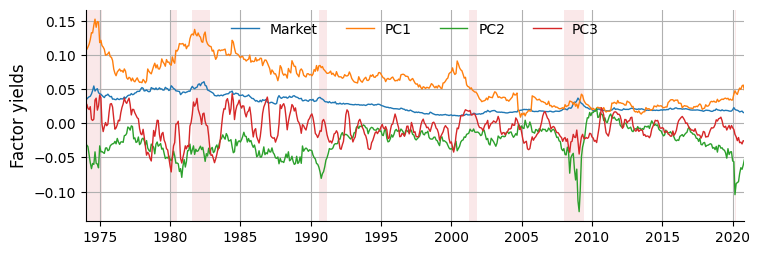

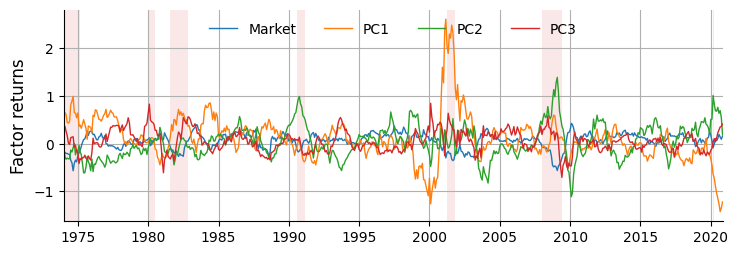

In [6]:
#%% FIGURE 1: Time-series of factor yields.
pf.timeseries_plot(F.index.values, F.iloc[:, npc:], se=None, filename=figpath+'Figure1',
                                        title='Factor yields', legends=[factor_titles[n] for n in factor_names])


#%% FIGURE 2: Time-series of factor returns.
pf.timeseries_plot(F.index.values, F.iloc[:, :npc], se=None, filename=figpath+'Figure2',
                                        title='Factor returns', legends=[factor_titles[n] for n in factor_names])



In [7]:
#%%
#| ## Estimation
# wrapper for scipy optimizer to work with Tensorflow
import external_optimizer_sk as o

fmt_npc = '{:^' + str(3*npc + 2) + '}'
fmt_mae_p = '{:^' + str(3*int(p_max_t/p_reporting_freq) + 2) + '}'


def estimate_state_space_model(variables_F_only, data_F, npc, oos_start_idx):
    #| ### Estimate the state space model (ignore all test assets)

    # state space optimization callback for logging
    def callback_state_space(j, outputs, variables):
        obj, m, u, stats = outputs
        R2u = stats['R2u']*100.0
    
        # print header
        if j % 30 == 0:
            print(('{:6}:  {:^12} '+fmt_npc+fmt_npc).format(
                    'step', 'obj', 'R2r_pcs', 'R2dp_pcs'))
    
        # print progress
        print(('{:6d}: {:12.9f} '+fmt_npc+fmt_npc).format(
                j, obj, vec2str(R2u[:npc]), vec2str(R2u[npc:])))
    
    # initialize the Scipy optimizer
    optimizer = o.ScipyOptimizerInterface(estimate_state_space, variables_F_only,
                                                                                method='BFGS', #'L-BFGS-B',
                                                                                options={'maxiter': 100000, 'disp': True,
                                                                                                'ftol': 1e-16, 'gtol': 1e-9})
    # estimate the state space model
    res = optimizer.minimize(extra_params=[data_F, npc, oos_start_idx],
                                                    loss_callback=callback_state_space)
    
    # store results
    variables_F_only = optimizer._vars
        
    return variables_F_only


if estimate_state_space_model:
    variables_F_only = estimate_state_space_model(variables_F_only, data_F, npc, oos_start_idx)
    timeit()

# use the state space estimates as initial guess in the full estimation
variables = variables_F_only + variables_test_assets_only

estimate_state_space_model = False

d:\github_repositories\gkk_2024\external_optimizer_sk.py:477: OptimizeWarning: Unknown solver options: ftol
  result = scipy.optimize.minimize(*minimize_args, **minimize_kwargs)


step  :      obj         R2r_pcs       R2dp_pcs   
     0: 6787.709371280   0| 0| 0| 0    0| 0| 0| 0  
     1: 6787.709371280   0| 0| 0| 0    0| 0| 0| 0  
     2: 227635.174709390 -520|-134|-34|-141-2755|-2595|-2027|-348
     3: 227635.174709390 -520|-134|-34|-141-2755|-2595|-2027|-348
     4: 10.809337337  16| 4| 1| 4   85|80|62|11  
     5: 10.809337337  16| 4| 1| 4   85|80|62|11  
     6:  1.292261481  16|12| 6| 6   93|96|68|13  
     7:  1.292261481  16|12| 6| 6   93|96|68|13  
     8:  1.167908260  16|12| 6| 7   93|96|68|14  
     9:  1.167908260  16|12| 6| 7   93|96|68|14  
    10:  5.569764793  17|13| 6| 8   92|96|68|14  
    11:  5.569764793  17|13| 6| 8   92|96|68|14  
    12:  1.164518108  17|12| 6| 7   93|96|68|14  
    13:  1.164518108  17|12| 6| 7   93|96|68|14  
    14:  1.157699322  17|12| 6| 7   93|96|68|14  
    15:  1.157699322  17|12| 6| 7   93|96|68|14  
    16:  1.131010587  17|13| 6| 7   93|96|68|14  
    17:  1.131010587  17|13| 6| 7   93|96|68|14  
    18:  1.03

./results/new_test/Figures/EY_mkt_ts_4pcs.pdf
step  :      obj      MCpen   R2r   R2dp     R2r_pcs       R2dp_pcs   PhPh_mkt
     0: 201.917388123 3e+00  86.17  93.94  20|22| 7|12   98|97|71|20      
   100: 16.536609516 3e+00  92.75  96.62  19|22| 7|12   98|97|71|20      
   200:  2.166727099 3e+00  93.37  96.82  19|22| 7|12   98|97|71|20      
   300:  1.889737032 3e+00  93.33  96.93  17|22| 7|12   98|97|71|20      
   400:  1.799921493 3e+00  93.30  97.19  12|22| 7|12   98|97|71|20      
   500:  1.773058798 2e+00  93.29  97.40  11|22| 7|12   98|97|71|20      
   600:  1.764321678 2e+00  93.29  97.54  11|22| 7|12   98|97|71|20      
   700:  1.753723583 2e+00  93.30  97.87  11|22| 7|12   98|97|71|20      
   800:  1.741872058 2e+00  93.30  98.06  11|22| 7|12   98|97|71|20      
   900:  1.736691004 1e+00  93.29  98.07  10|22| 7|12   98|97|71|20      
  1000:  1.734983063 1e+00  93.29  98.08  10|22| 7|12   98|97|71|20      
  1100:  1.733305177 9e-01  93.29  98.21  10|22| 7|12   98|9

d:\Python313\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


./results/new_test/Figures/EY_mkt_ts_4pcs.pdf
step  :      obj      MCpen   R2r   R2dp     R2r_pcs       R2dp_pcs   PhPh_mkt
     0:  1.732297325 1e-15  93.29  98.72  10|22| 7|12   98|97|71|20      
  42.81s elapsed.


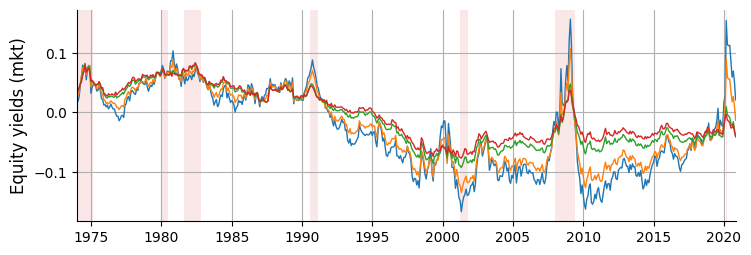

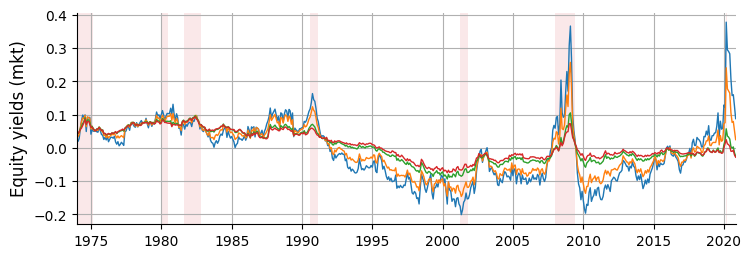

In [8]:
#%%
def estimate_main_model(dates, variables, data, W, npc, oos_start_idx):

    #| ### Estimate the joint model (main estimation loop)

    # joint estimation callback for logging
    def callback_full_model(j, outputs, variables):
        #obj, mc_pen, m, e, stats, EY = outputs
        max_maturity = bonds_max_maturity
        mkt_idx = 0

        if j % 100 == 0:
            obj, m, stats, series, _ = compute_strips_prices(variables, W, data, npc, N, oos_start_idx)

            # print header
            if j % 3000 == 0:
                pf.timeseries_plot(dates.values, tf.stack([series['EY'][i-1, :, mkt_idx] for i in (1, 2, 5, 7)]).numpy().T,
                                                        title='Equity yields (mkt)', filename=figpath+'EY_mkt_ts_{}pcs'.format(npc))
                print(('{:6}:  {:^12}{:^7}{:^7}{:^7}'+fmt_npc+fmt_npc+fmt_mae_p+fmt_mae_p).format(
                        'step', 'obj', 'MCpen', 'R2r', 'R2dp', 'R2r_pcs', 'R2dp_pcs', 'Ph', 'Ph_mkt'))

            # print progress
            R2u = stats['R2u']*100.0
            print(('{:6d}: {:12.9f} {:.0e}{:7.2f}{:7.2f} '+fmt_npc+fmt_npc+fmt_mae_p+fmt_mae_p).format(
                    j, obj, stats['pen'], 100.0*stats['R2r'], 100.0*stats['R2dp'],
                    vec2str(R2u[:npc]), vec2str(R2u[npc:]),
                    vec2str(stats['mae_p']*100.0), vec2str(stats['mae_pm']*100.0)))

    # initialize the Scipy optimizer
    optimizer = o.ScipyOptimizerInterface(estimate_full_model, variables,
                                            method='BFGS', # L-BFGS-B, CG, TNC, BFGS
                                            options={'maxiter': 10000, 'disp': True,
                                                            'ftol': 1e-16, 'gtol': 1e-9})
    # estimate the joint model
    extra_params = [W, data, npc, N, oos_start_idx]#, S1] # S1 = tfp.math.pinv(S)
    res = optimizer.minimize(extra_params=extra_params,
                                                    loss_callback=callback_full_model)

    # store results
    variables = optimizer._vars

    # report and plot final estimates
    callback_full_model(0, [], variables)

    return optimizer, extra_params, variables



optimizer, optimizer_extra_params, variables = estimate_main_model(dates, variables, data, W, npc, oos_start_idx)

# unpack results
c, rho_r, rho_dp, test_beta2_ur, test_b0, test_b1_dp = variables

# save the estimates
if output_intermediate_data_results:
    sv.save_data(variables, 'variables', path=respath)  

# compute all variables of interest for a fully estimated model
obj, m, stats, series, _ = compute_strips_prices(variables, W, data, npc, N, oos_start_idx)
if output_intermediate_data_results:
    sv.save_data(obj, 'obj', path=respath)  
    sv.save_data(stats, 'stats', path=respath)  
    sv.save_data(series, 'series', path=respath)  

timeit()


In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from constants import *
import matplotlib.pyplot as plt
import math

series = pd.read_pickle('results/new_test/series.pickle')
input_data = pd.read_pickle('results/new_test/input_data.pickle')
P = tf.convert_to_tensor(series['P'], dtype=float)
DP = tf.convert_to_tensor(series['DP'], dtype=float)

F = pd.read_csv('results/new_test/Tables/F.csv', index_col=0)
dd = F.index
F = tf.convert_to_tensor(F, dtype=float)

input_data = pd.read_pickle('results/new_test/input_data.pickle')
rx, dp, test_asset_ret, test_asset_dps, rme, dpm, by, fs, brx, labels, AnomalyNames = input_data
test_asset_ret = test_asset_ret.rolling(window=L).sum()
test_assets = [v[:-1] for v in test_asset_ret.columns[:51]]
test_asset_ret = tf.convert_to_tensor(test_asset_ret.loc[dd], dtype=float)

_, N = test_asset_ret.shape
sh = tf.TensorShape((F.shape[0], N+npc))
ret_idx = slice(0, npc)

In [2]:
# pd         = -tf.math.log(tf.math.exp(DP) - 1.0)
R          = tf.concat([F[:, ret_idx], test_asset_ret], axis=1) 
# dg_rf      = R[L:,:] - DP[L:,:] - pd[L:,:] + pd[:-L,:] 
r1         = tf.math.exp(R - DP)[L:,:]*(tf.math.exp(DP[L:,:]) - 1.0) / P[0, :-L, :] - 1.0 # CHECK! There might be a mistake here (need to use future R & DP ?)
r          =  tf.concat([tf.reshape(r1, [1, sh[0]-L, N+npc]), # HTM return for 1 year
                P[:-1, L:, :] / P[1:, :-L, :] * tf.math.exp(R - DP)[L:, :] - 1.0], axis=0) # returns with maturity above 1 year
r_slope7_1 = r[6:7, :, :] - r[0:1, :, :] # 7-1 slope needs to be computed here if standard errors are needed
log_r = tf.math.log(r + 1) # conver annually raw strips return to montly log return

check_r_slope7_1 = tf.convert_to_tensor(series['r_slope7_1'], dtype=float)
check_dg_rf = tf.convert_to_tensor(series['dgrf'], dtype=float)

assert tf.reduce_max(tf.abs(r_slope7_1 - check_r_slope7_1)) < 1e-2

In [3]:
ls_ret = r[:, :, 4:55] - r[:, :, 55:]
ls_ret_mean = pd.DataFrame(tf.reduce_mean(ls_ret, axis=1), columns=test_assets)
log_ls_ret = log_r[:, :, 4:55] - log_r[:, :, 55:]
log_ls_ret_mean = pd.DataFrame(tf.reduce_mean(ls_ret, axis=1), columns=test_assets)

In [4]:
anom_to_plot = ['size', 'value', 'mom12', 'growth', 'prof', 'strev', 'ivol', 'age']
overreaction_anom  = ['cfp', 'divp', 'dur', 'ep', 'lrrev', 'sgrowth', 'value', 'valuem']
financial_constraint_anom = ['ivol', 'roaa', 'roa', 'roe', 'roea', 'prof']

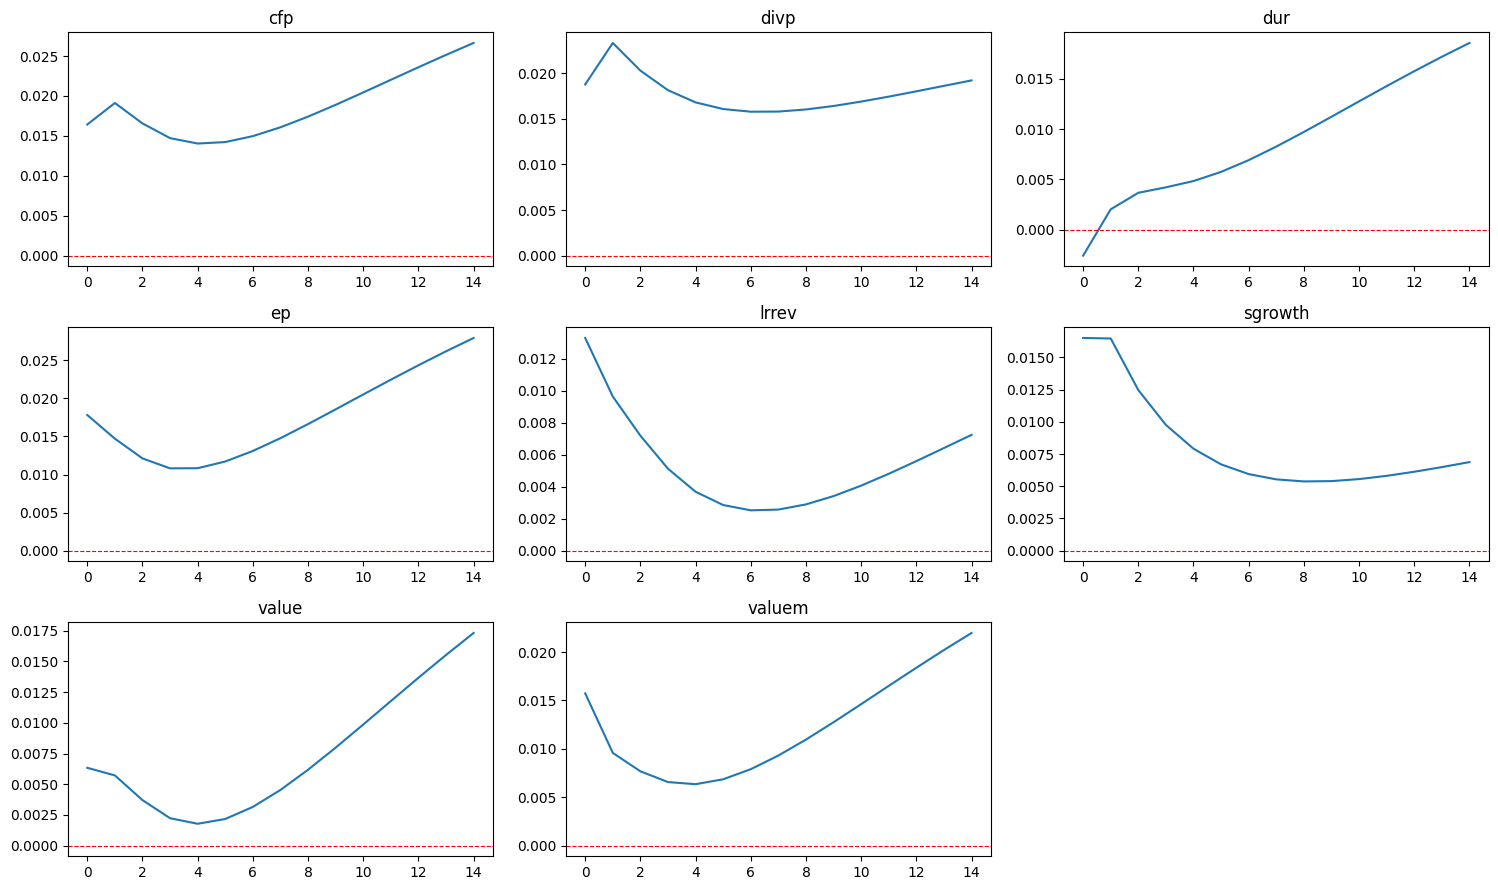

In [5]:
import matplotlib.pyplot as plt
import math

df = ls_ret_mean[overreaction_anom]
ncols = 3
nrows = math.ceil(len(df.columns) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].plot(df[col])
    axes[i].set_title(col)
    axes[i].axhline(0, color='red', linestyle='--', linewidth=0.8)

# 隐藏多余子图
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
rme = R[L:, 0:1]
X = tf.concat([tf.ones((551, 1), dtype=rme.dtype), rme], axis=1)
Y = tf.reshape(tf.transpose(ls_ret, [1, 0, 2]), [551, 15 * 51])

coeffs = tf.linalg.lstsq(X, Y)

alpha = Y - X[:, 1:] @ coeffs[1:, :]
alpha = tf.transpose(tf.reshape(alpha, [alpha.shape[0], 15, 51]), [1, 0, 2])
alpha = alpha[1:]

In [7]:
def creat_maturity_table(variable, vnames):
    diff = variable[-1] - variable[0]
    mean_diff = tf.reduce_mean(diff, axis=0)
    std_diff  = tf.math.reduce_std(diff, axis=0)
    t_values  = mean_diff / (std_diff / tf.sqrt(float(diff.shape[0])))

    df = pd.DataFrame(tf.reduce_mean(variable, axis=1), columns=vnames)
    diff_t = pd.DataFrame(tf.concat([tf.reshape(mean_diff, [-1, 1]), tf.reshape(t_values, [-1, 1])], axis=1), columns=['14-1', 'tvalue'], index=vnames).T
    df = pd.concat([df, diff_t], axis=0)
    
    return df

In [8]:
df1 = creat_maturity_table(alpha, test_assets)
df2 = creat_maturity_table(ls_ret, test_assets)
df1.T.to_csv('test/alpha_to_maturity.csv')
df2.T.to_csv('test/return_to_maturity.csv')